# CompareAtlases: Cell x Gene Explorer

This notebook loads atlas/HCR cell x gene tables created by `run_collect_reference_atlas_cellxgene.py`,
lets you choose a custom gene order, and replots using `aind_hcr_qc.viz.plot_cell_x_gene_clustered`.

## How to use
1. Run the import/helpers cell.
2. Run the discovery cell to list available `cell_x_gene.csv` files.
3. In the parameter cell, set `TABLE_KEY` and `GENE_ORDER_TEXT`.
4. Run the plotting cell to generate clustered cell x gene plots.
5. Optional: set `SAVE_REORDERED_CSV = True` to write a reordered CSV.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import aind_hcr_qc.viz as viz

REFERENCE_ROOT = Path("/root/capsule/scratch/reference_atlas_cellxgene")


def discover_cellxgene_tables(root: Path = REFERENCE_ROOT) -> dict[str, Path]:
    """Find all generated cell_x_gene.csv tables under the reference output root."""
    tables: dict[str, Path] = {}
    for csv_path in sorted(root.glob("**/cell_x_gene.csv")):
        rel_parent = csv_path.parent.relative_to(root).as_posix()
        key = rel_parent if rel_parent != "." else "root"
        tables[key] = csv_path
    return tables


def load_cellxgene_table(table_path: Path) -> pd.DataFrame:
    return pd.read_csv(table_path, index_col=0)


def parse_gene_order(
    gene_text: str,
    available_genes: list[str],
    append_missing: bool = True,
) -> tuple[list[str], list[str]]:
    requested = [g.strip() for g in gene_text.replace("\n", ",").split(",") if g.strip()]
    requested = list(dict.fromkeys(requested))

    if not requested:
        return available_genes.copy(), []

    present = [g for g in requested if g in available_genes]
    missing = [g for g in requested if g not in available_genes]

    if append_missing:
        remaining = [g for g in available_genes if g not in present]
        ordered = present + remaining
    else:
        ordered = present

    return ordered, missing


def subset_and_order_genes(
    cxg: pd.DataFrame,
    gene_text: str,
    append_missing: bool = True,
) -> tuple[pd.DataFrame, list[str]]:
    available = cxg.columns.astype(str).tolist()
    ordered_genes, missing = parse_gene_order(
        gene_text,
        available,
        append_missing=append_missing,
    )
    if not ordered_genes:
        raise ValueError("No genes left after applying gene order filter.")
    return cxg.loc[:, ordered_genes].copy(), missing


def maybe_subsample_cells(cxg: pd.DataFrame, max_cells: int, random_seed: int) -> pd.DataFrame:
    if max_cells > 0 and len(cxg) > max_cells:
        return cxg.sample(n=max_cells, random_state=random_seed)
    return cxg


def plot_clustered_with_viz(
    cxg: pd.DataFrame,
    title: str,
    k: int = 20,
    clip_max: float = 200.0,
    fig_size: tuple[float, float] | None = None,
    cluster_method: str = "kmeans",
    cluster_sort_gene: str = "Gad2",
    add_cluster_labels: bool = False,
):
    if fig_size is None:
        n_cells, n_genes = cxg.shape
        fig_w = float(np.clip(4.0 + 0.06 * n_genes, 8.0, 42.0))
        fig_h = float(np.clip(4.0 + 0.015 * n_cells, 8.0, 48.0))
        fig_size = (fig_w, fig_h)

    fig, cluster_labels, sorted_cell_ids = viz.plot_cell_x_gene_clustered(
        cxg,
        clip_range=(0, clip_max),
        fig_size=fig_size,
        k=k,
        cluster_method=cluster_method,
        add_cluster_labels=add_cluster_labels,
        title=title,
        gene_sort=None,
        cluster_sort_gene=cluster_sort_gene,
    )
    plt.show()
    return fig, cluster_labels, sorted_cell_ids

In [2]:
tables = discover_cellxgene_tables()

print(f"Reference root: {REFERENCE_ROOT}")
print(f"Found {len(tables)} table(s).")
for key, path in tables.items():
    print(f"- {key}: {path}")

if not tables:
    print("No tables found. Run run_collect_reference_atlas_cellxgene.py first.")

Reference root: /root/capsule/scratch/reference_atlas_cellxgene
Found 4 table(s).
- 10x-hmb: /root/capsule/scratch/reference_atlas_cellxgene/10x-hmb/cell_x_gene.csv
- hcr/790322: /root/capsule/scratch/reference_atlas_cellxgene/hcr/790322/cell_x_gene.csv
- merfish: /root/capsule/scratch/reference_atlas_cellxgene/merfish/cell_x_gene.csv
- tasic: /root/capsule/scratch/reference_atlas_cellxgene/tasic/cell_x_gene.csv


In [3]:
GENE_ORDER = [
    "Gad2",
    "Slc17a7",
    "Calb1",
    "Calb2",
    "Cck",
    "Chat",
    "Crh",
    "Hpse",
    "Mme",
    "Ndnf",
    "Npy",
    "Pdyn",
    "Penk",
    "Pthlh",
    "Tac1",
    "Tac2",
    "Reln",
    "Lamp5",
    "Pvalb",
    "Sst",
    "Vip",
]

# Convert to the format expected by parse_gene_order().
GENE_ORDER_TEXT = "\n".join(GENE_ORDER)
print(f"Gene order set with {len(GENE_ORDER)} genes.")

Gene order set with 21 genes.


Table key: 10x-hmb
Source: /root/capsule/scratch/reference_atlas_cellxgene/10x-hmb/cell_x_gene.csv
Raw shape: 47,030 cells x 21 genes
Plot shape: 12,000 cells x 21 genes


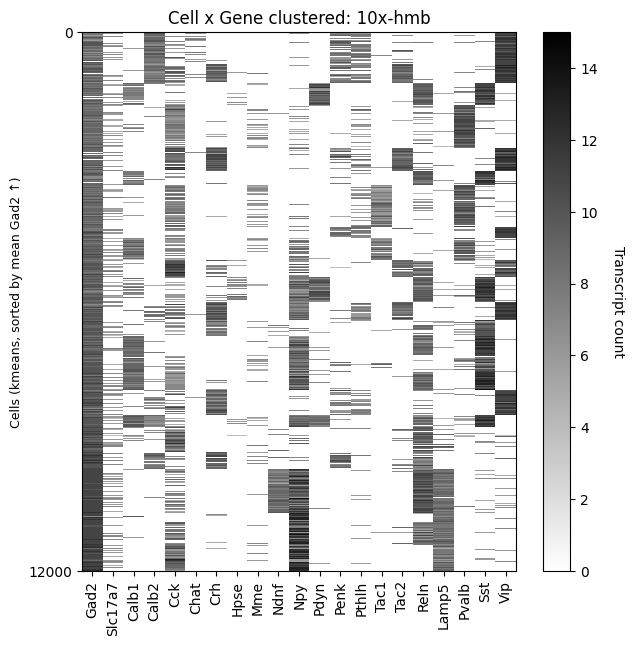

In [6]:
if not tables:
    raise RuntimeError("No cell_x_gene tables discovered. Run the discovery cell after generating data.")

# Set these parameters, then run this cell.
TABLE_KEY = "10x-hmb"
GENE_ORDER_TEXT = "\n".join(GENE_ORDER)  # Uses the gene ordering cell above.
APPEND_MISSING_GENES = True

MAX_CELLS = 12000
RANDOM_SEED = 42

K = 24
CLIP_MAX = 3000.0
CLUSTER_METHOD = "kmeans"  # kmeans, agglomerative, ward_leaf
CLUSTER_SORT_GENE = "Gad2"
SHOW_CLUSTER_LABELS = False  # Set True to show cluster lines/labels.

SAVE_REORDERED_CSV = False
SAVE_FILENAME = "cell_x_gene_reordered.csv"

print(f"Table key: {TABLE_KEY}")
print(f"Source: {tables[TABLE_KEY]}")

cxg_raw = load_cellxgene_table(tables[TABLE_KEY])
print(f"Raw shape: {cxg_raw.shape[0]:,} cells x {cxg_raw.shape[1]:,} genes")

cxg_ordered, missing_genes = subset_and_order_genes(
    cxg_raw,
    GENE_ORDER_TEXT,
    append_missing=APPEND_MISSING_GENES,
)

if missing_genes:
    print(f"Missing genes skipped: {missing_genes}")

cxg_plot = maybe_subsample_cells(cxg_ordered, max_cells=MAX_CELLS, random_seed=RANDOM_SEED)
print(f"Plot shape: {cxg_plot.shape[0]:,} cells x {cxg_plot.shape[1]:,} genes")

fig, cluster_labels, sorted_cell_ids = plot_clustered_with_viz(
    cxg_plot,
    title=f"Cell x Gene clustered: {TABLE_KEY}",
    k=K,
    clip_max=CLIP_MAX,
    cluster_method=CLUSTER_METHOD,
    cluster_sort_gene=CLUSTER_SORT_GENE,
    add_cluster_labels=SHOW_CLUSTER_LABELS,
    fig_size=(7, 7),
)

if SAVE_REORDERED_CSV:
    out_path = tables[TABLE_KEY].parent / SAVE_FILENAME
    cxg_ordered.to_csv(out_path)
    print(f"Saved reordered CSV: {out_path}")


[10x-hmb] raw=(47030, 21), plot=(12000, 21)


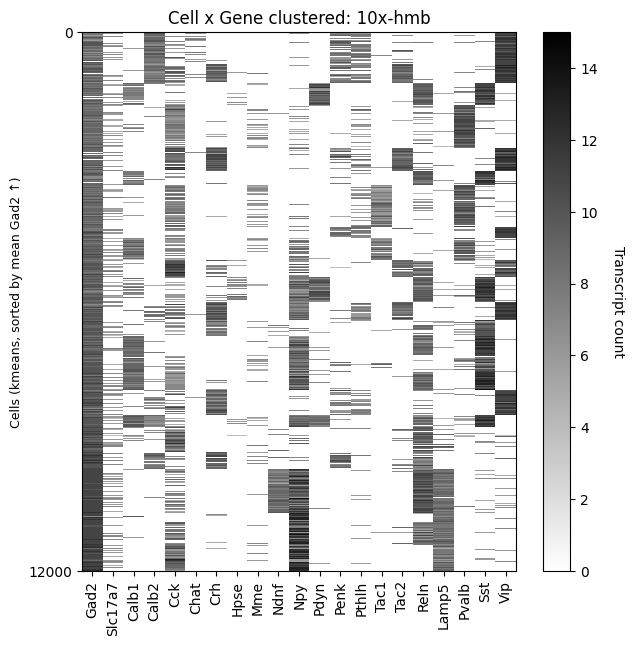


[hcr/790322] raw=(7674, 21), plot=(7674, 21)


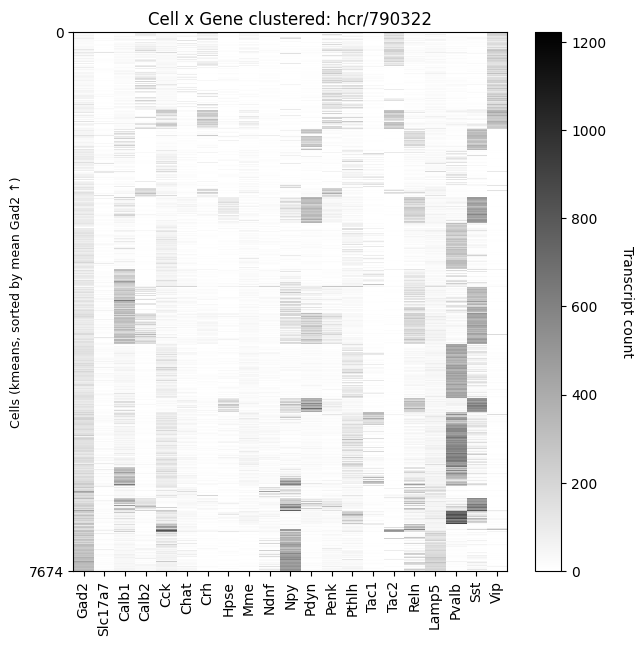


[merfish] raw=(4301, 14), plot=(4301, 14)
Missing genes skipped: ['Cck', 'Hpse', 'Mme', 'Npy', 'Pthlh', 'Tac1', 'Sst']


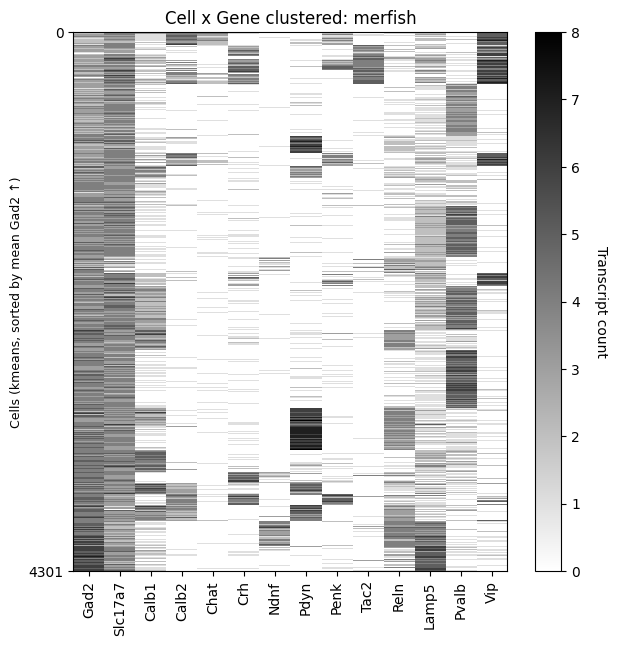


[tasic] raw=(5331, 21), plot=(5331, 21)


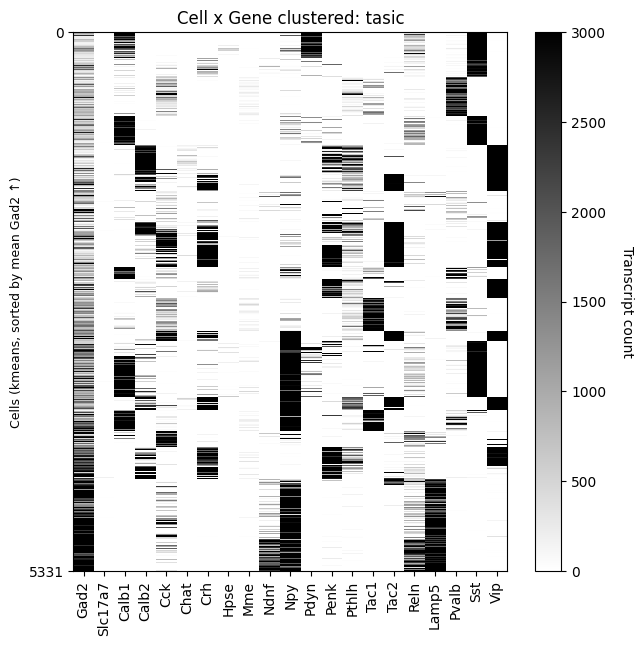

In [32]:
# Optional: compare multiple tables with the same gene order in one run.
SELECTED_KEYS = list(tables.keys())
GENE_ORDER_TEXT_MULTI = "\n".join(GENE_ORDER)
SHOW_CLUSTER_LABELS_MULTI = False  # Set True to show cluster lines/labels.

for table_key in SELECTED_KEYS:
    cxg_raw = load_cellxgene_table(tables[table_key])
    cxg_ordered, missing = subset_and_order_genes(
        cxg_raw,
        GENE_ORDER_TEXT_MULTI,
        append_missing=True,
    )
    cxg_plot = maybe_subsample_cells(cxg_ordered, max_cells=MAX_CELLS, random_seed=RANDOM_SEED)

    print(f"\n[{table_key}] raw={cxg_raw.shape}, plot={cxg_plot.shape}")
    if missing:
        print(f"Missing genes skipped: {missing}")

    plot_clustered_with_viz(
        cxg_plot,
        title=f"Cell x Gene clustered: {table_key}",
        k=K,
        clip_max=CLIP_MAX,
        cluster_method=CLUSTER_METHOD,
        cluster_sort_gene=CLUSTER_SORT_GENE,
        add_cluster_labels=SHOW_CLUSTER_LABELS_MULTI,
        fig_size=(7, 7),
    )